# جزوه پروژه‌محور Data Science با Python
## NumPy + Pandas + Matplotlib + نیم‌نگاهی به Scikit-learn

در این نوت‌بوک چهار ابزار مهم مسیر شروع Data Science را **در قالب یک پروژه واقعی و یکپارچه** یاد می‌گیریم:

- **NumPy** برای محاسبات عددی و آرایه‌ها
- **Pandas** برای خواندن، بررسی، پاک‌سازی و تحلیل داده‌های جدولی
- **Matplotlib** برای Visualization
- **Scikit-learn** برای آماده‌سازی داده، ساخت اولین مدل Machine Learning و ارزیابی آن

### پروژه اصلی

در فایل `students_100.csv` اطلاعات **100 دانشجو** قرار دارد.

ستون‌ها:

| ستون | توضیح |
|---|---|
| `student_id` | شناسه دانشجو |
| `name` | نام |
| `age` | سن |
| `city` | شهر |
| `study_hours` | ساعات مطالعه |
| `attendance` | درصد حضور |
| `score` | نمره |

هدف ما این است که از داده خام شروع کنیم و مرحله‌به‌مرحله به یک مدل ساده برای **پیش‌بینی نمره** برسیم.

> نکته: این Dataset آموزشی است و برای یادگیری طراحی شده است؛ بنابراین قرار نیست نماینده یک جامعه واقعی باشد.


# 1. نقشه راه پروژه

کل مسیر را به شکل زیر طی می‌کنیم:

```text
CSV
 ↓
Pandas
 ↓
بررسی Dataset
 ↓
Data Cleaning
 ↓
تحلیل آماری
 ↓
NumPy
 ↓
Visualization با Matplotlib
 ↓
Feature / Target
 ↓
Train / Test Split
 ↓
Scikit-learn
 ↓
Linear Regression
 ↓
Prediction
 ↓
Evaluation
```

یک اصل بسیار مهم:

> در Data Science معمولاً قبل از ساخت مدل باید داده را بشناسیم، تمیز کنیم و تحلیل کنیم.


# 2. نصب کتابخانه‌ها

در صورت نیاز، در محیط ترمینال یا Jupyter می‌توان نصب را انجام داد:

```bash
pip install numpy pandas matplotlib scikit-learn
```

در این نوت‌بوک از کتابخانه‌های زیر استفاده می‌کنیم:

- `numpy` با نام `np`
- `pandas` با نام `pd`
- `matplotlib.pyplot` با نام `plt`
- بخش‌هایی از `scikit-learn`


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully.")

Libraries imported successfully.


# 3. آشنایی سریع با NumPy

`NumPy` برای کار با داده‌های عددی بسیار مهم است.

مهم‌ترین مفهوم آن `ndarray` است.

## ساخت آرایه

```python
numbers = np.array([10, 20, 30, 40])
```

## ویژگی‌های مهم

```python
numbers.shape
numbers.ndim
numbers.size
numbers.dtype
```

## توابع کاربردی

```python
np.mean()
np.median()
np.min()
np.max()
np.sum()
np.std()
```

یکی از مزیت‌های مهم NumPy این است که می‌توان عملیات را روی کل آرایه انجام داد.


In [2]:
numbers = np.array([10, 20, 30, 40, 50])

print("Array:", numbers)
print("Shape:", numbers.shape)
print("Dimensions:", numbers.ndim)
print("Size:", numbers.size)
print("Data type:", numbers.dtype)

print("Mean:", np.mean(numbers))
print("Median:", np.median(numbers))
print("Min:", np.min(numbers))
print("Max:", np.max(numbers))
print("Sum:", np.sum(numbers))
print("Std:", np.std(numbers))

Array: [10 20 30 40 50]
Shape: (5,)
Dimensions: 1
Size: 5
Data type: int64
Mean: 30.0
Median: 30.0
Min: 10
Max: 50
Sum: 150
Std: 14.142135623730951


## آرایه دوبعدی NumPy

در Data Science اغلب با داده‌هایی شبیه جدول روبه‌رو هستیم:

```text
row × column
```

مثال:


In [3]:
matrix = np.array([
    [10, 20, 30],
    [40, 50, 60]
])

print(matrix)
print("Shape:", matrix.shape)
print("First row:", matrix[0])
print("Value at row 0, column 1:", matrix[0, 1])

[[10 20 30]
 [40 50 60]]
Shape: (2, 3)
First row: [10 20 30]
Value at row 0, column 1: 20


# 4. خواندن فایل CSV با Pandas

اکنون وارد بخش اصلی پروژه می‌شویم.

فایل `students_100.csv` در کنار این Notebook قرار گرفته است.

دستور اصلی:

```python
df = pd.read_csv("students_100.csv")
```

خروجی یک `DataFrame` است.

یعنی:

```text
students_100.csv
      ↓
pd.read_csv()
      ↓
DataFrame
```


In [4]:
df = pd.read_csv("students_100.csv")

print(df.head())

   student_id     name  age     city  study_hours  attendance  score
0           1     Mina   18   Tabriz            4          74     52
1           2     Mina   28  Isfahan            2          97     63
2           3     Sara   18   Tehran            4          74     64
3           4  Nazanin   18  Isfahan            4          94     71
4           5   Hassan   25  Isfahan            5          60     51


## چرا CSV مهم است؟

در پروژه‌های واقعی معمولاً داده را داخل کد نمی‌نویسیم.

داده می‌تواند از:

- فایل CSV
- Excel
- Database
- API
- سنسورها
- سیستم‌های نرم‌افزاری

بیاید.

CSV یکی از ساده‌ترین فرمت‌ها برای تبادل داده است.


# 5. بررسی اولیه Dataset

اول باید بفهمیم چه داده‌ای داریم.

دستورات بسیار مهم:

```python
df.head()
df.tail()
df.shape
df.columns
df.info()
df.describe()
```


In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

Shape: (100, 7)

Columns:
['student_id', 'name', 'age', 'city', 'study_hours', 'attendance', 'score']

First 5 rows:


,student_id,name,age,city,study_hours,attendance,score
0,1,Mina,18,Tabriz,4,74,52
1,2,Mina,28,Isfahan,2,97,63
2,3,Sara,18,Tehran,4,74,64
3,4,Nazanin,18,Isfahan,4,94,71
4,5,Hassan,25,Isfahan,5,60,51



Last 5 rows:


,student_id,name,age,city,study_hours,attendance,score
95,96,Maryam,30,Isfahan,8,100,89
96,97,Maryam,25,Tehran,5,75,62
97,98,Parsa,23,Isfahan,2,68,39
98,99,Hassan,24,Shiraz,4,64,56
99,100,Negar,23,Isfahan,8,86,76


In [6]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   student_id   100 non-null    int64
 1   name         100 non-null    str  
 2   age          100 non-null    int64
 3   city         100 non-null    str  
 4   study_hours  100 non-null    int64
 5   attendance   100 non-null    int64
 6   score        100 non-null    int64
dtypes: int64(5), str(2)
memory usage: 5.6 KB


In [7]:
print("Descriptive statistics:")
display(df.describe())

Descriptive statistics:


,student_id,age,study_hours,attendance,score
count,100.000000,100.000000,100.000000,100.000000,100.000000
mean,50.500000,23.960000,5.770000,79.650000,67.920000
std,29.011492,3.711625,2.852803,11.817104,16.711866
min,1.000000,18.000000,1.000000,60.000000,35.000000
25%,25.750000,21.000000,4.000000,70.000000,53.000000
50%,50.500000,24.000000,6.000000,76.500000,69.000000
75%,75.250000,28.000000,8.000000,93.000000,81.000000
max,100.000000,30.000000,10.000000,100.000000,100.000000


# 6. بررسی Missing Value و Duplicate

در Dataset واقعی باید حتماً وجود داده‌های ناقص و تکراری را بررسی کنیم.

## Missing Value

```python
df.isnull().sum()
```

## Duplicate

```python
df.duplicated().sum()
```

در این Dataset انتظار داریم داده کامل و بدون رکورد تکراری داشته باشیم.


In [8]:
print("Missing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:


student_id     0
name           0
age            0
city           0
study_hours    0
attendance     0
score          0
dtype: int64


Duplicate rows: 0


# 7. انتخاب ستون‌ها و ردیف‌ها

## یک ستون

```python
df["score"]
```

## چند ستون

```python
df[["name", "city", "score"]]
```

## چند ردیف اول

```python
df.iloc[:5]
```

## انتخاب با شرط

```python
df[df["score"] > 90]
```


In [9]:
scores = df["score"]
selected_columns = df[["name", "city", "study_hours", "score"]]

print("Score column:")
display(scores.head())

print("\nSelected columns:")
display(selected_columns.head())

Score column:


0    52
1    63
2    64
3    71
4    51
Name: score, dtype: int64


Selected columns:


,name,city,study_hours,score
0,Mina,Tabriz,4,52
1,Mina,Isfahan,2,63
2,Sara,Tehran,4,64
3,Nazanin,Isfahan,4,71
4,Hassan,Isfahan,5,51


# 8. فیلتر کردن داده

فیلتر یکی از مهم‌ترین مهارت‌های Pandas است.

### دانشجویان ممتاز

```python
df[df["score"] > 90]
```

### دانشجویان با مطالعه زیاد

```python
df[df["study_hours"] >= 8]
```

### چند شرط

در Pandas معمولاً برای AND از `&` و برای OR از `|` استفاده می‌کنیم:

```python
df[
    (df["study_hours"] > 6) &
    (df["score"] > 80)
]
```


In [10]:
excellent = df[df["score"] > 90]
heavy_study = df[df["study_hours"] >= 8]
strong_students = df[
    (df["study_hours"] > 6) &
    (df["score"] > 80)
]

print("Students with score > 90:")
display(excellent.head(10))

print("\nStudents with study_hours >= 8:")
display(heavy_study.head(10))

print("\nStudents with study_hours > 6 AND score > 80:")
display(strong_students.head(10))

Students with score > 90:


,student_id,name,age,city,study_hours,attendance,score
24,25,Mina,28,Tabriz,9,98,93
31,32,Sina,24,Tabriz,8,93,93
36,37,Zahra,26,Shiraz,10,96,100
48,49,Parsa,18,Tehran,10,90,100
52,53,Negar,28,Isfahan,10,93,99
84,85,Negar,30,Isfahan,10,80,96



Students with study_hours >= 8:


,student_id,name,age,city,study_hours,attendance,score
7,8,Nazanin,22,Tehran,8,94,82
12,13,Reza,27,Shiraz,9,75,80
13,14,Arman,24,Tabriz,9,74,84
17,18,Hassan,29,Isfahan,9,76,88
23,24,Ali,29,Tabriz,9,71,89
24,25,Mina,28,Tabriz,9,98,93
25,26,Amir,23,Shiraz,9,93,84
29,30,Amir,28,Mashhad,9,70,80
31,32,Sina,24,Tabriz,8,93,93
33,34,Mehdi,26,Shiraz,10,74,79



Students with study_hours > 6 AND score > 80:


,student_id,name,age,city,study_hours,attendance,score
7,8,Nazanin,22,Tehran,8,94,82
13,14,Arman,24,Tabriz,9,74,84
17,18,Hassan,29,Isfahan,9,76,88
20,21,Negar,27,Tehran,7,84,83
23,24,Ali,29,Tabriz,9,71,89
24,25,Mina,28,Tabriz,9,98,93
25,26,Amir,23,Shiraz,9,93,84
31,32,Sina,24,Tabriz,8,93,93
36,37,Zahra,26,Shiraz,10,96,100
42,43,Arman,21,Tehran,8,95,83


# 9. مرتب‌سازی

برای مرتب‌سازی:

```python
df.sort_values("score")
```

برای مرتب‌سازی نزولی:

```python
df.sort_values("score", ascending=False)
```

از این تکنیک برای پیدا کردن Top N رکوردها بسیار استفاده می‌کنیم.


In [33]:
top_10 = df.sort_values(
    "score",
    ascending=False
).head(10)

print("Top 10 students:")
display(top_10)

Top 10 students:


,student_id,name,age,city,study_hours,attendance,score,passed,grade
48,49,Parsa,18,Tehran,10,90,100,True,Excellent
36,37,Zahra,26,Shiraz,10,96,100,True,Excellent
52,53,Negar,28,Isfahan,10,93,99,True,Excellent
84,85,Negar,30,Isfahan,10,80,96,True,Excellent
24,25,Mina,28,Tabriz,9,98,93,True,Excellent
31,32,Sina,24,Tabriz,8,93,93,True,Excellent
80,81,Mina,29,Tabriz,9,79,90,True,Good
95,96,Maryam,30,Isfahan,8,100,89,True,Good
58,59,Aida,29,Tabriz,10,93,89,True,Good
93,94,Arman,27,Isfahan,7,95,89,True,Good


# 10. آمار پایه با Pandas

اکنون چند سؤال ساده از Dataset می‌پرسیم:

1. میانگین نمره چیست؟
2. بیشترین نمره چیست؟
3. کمترین نمره چیست؟
4. میانگین ساعات مطالعه چقدر است؟
5. میانگین حضور چقدر است؟


In [12]:
print("Average score:", df["score"].mean())
print("Maximum score:", df["score"].max())
print("Minimum score:", df["score"].min())
print("Average study hours:", df["study_hours"].mean())
print("Average attendance:", df["attendance"].mean())

Average score: 67.92
Maximum score: 100
Minimum score: 35
Average study hours: 5.77
Average attendance: 79.65


# 11. GroupBy

یکی از قدرتمندترین قابلیت‌های Pandas:

```python
groupby()
```

مثلاً می‌خواهیم بدانیم در هر شهر چند دانشجو داریم:


In [13]:
print("Number of students in each city:")
display(df["city"].value_counts())

Number of students in each city:


city
Isfahan    26
Tehran     22
Tabriz     21
Mashhad    16
Shiraz     15
Name: count, dtype: int64

### میانگین نمره در هر شهر

```python
df.groupby("city")["score"].mean()
```

این الگوی تحلیلی خیلی مهم است:

> یک متغیر را بر اساس یک گروه یا دسته‌بندی خلاصه کن.


In [43]:
city_score = df.groupby("city")["score"].mean()

print("Average score by city:")
display(city_score.sort_values(ascending=False))

Average score by city:


city
Shiraz     70.600000
Isfahan    70.384615
Tabriz     69.095238
Tehran     65.090909
Mashhad    63.750000
Name: score, dtype: float64

# 12. چند Aggregation به صورت همزمان

با `agg()` می‌توانیم چند معیار را یکجا محاسبه کنیم:

```python
df.groupby("city")["score"].agg(
    ["count", "mean", "min", "max"]
)
```


In [15]:
city_summary = df.groupby("city")["score"].agg(
    ["count", "mean", "min", "max"]
)

display(city_summary.sort_values("mean", ascending=False))

,count,mean,min,max
city,,,,
Shiraz,15,70.600000,41,100
Isfahan,26,70.384615,35,99
Tabriz,21,69.095238,41,93
Tehran,22,65.090909,40,100
Mashhad,16,63.750000,40,87


# 13. ساخت Feature جدید

می‌توانیم از داده‌های موجود، ستون جدید بسازیم.

مثلاً ستون `passed`:

- اگر نمره >= 50 باشد: `True`
- در غیر این صورت: `False`



In [16]:
df["passed"] = df["score"] >= 50

display(df[["name", "score", "passed"]].head(10))

,name,score,passed
0,Mina,52,True
1,Mina,63,True
2,Sara,64,True
3,Nazanin,71,True
4,Hassan,51,True
5,Negar,52,True
6,Mina,53,True
7,Nazanin,82,True
8,Omid,78,True
9,Mehdi,41,False


## دسته‌بندی نمره‌ها

مثلاً:

- 0 تا کمتر از 50 → Weak
- 50 تا کمتر از 70 → Average
- 70 تا کمتر از 90 → Good
- 90 تا 100 → Excellent

برای این کار می‌توان از `pd.cut()` استفاده کرد.


In [17]:
bins = [0, 50, 70, 90, 100]
labels = ["Weak", "Average", "Good", "Excellent"]

df["grade"] = pd.cut(
    df["score"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

display(df[["name", "score", "grade"]].head(10))

print("\nNumber of students in each grade:")
display(df["grade"].value_counts())

,name,score,grade
0,Mina,52,Average
1,Mina,63,Average
2,Sara,64,Average
3,Nazanin,71,Good
4,Hassan,51,Average
5,Negar,52,Average
6,Mina,53,Average
7,Nazanin,82,Good
8,Omid,78,Good
9,Mehdi,41,Weak



Number of students in each grade:


grade
Good         41
Average      35
Weak         18
Excellent     6
Name: count, dtype: int64

# 14. ارتباط NumPy و Pandas

Pandas بر مبنای ساختارهای عددی قدرتمند NumPy کار می‌کند.

می‌توانیم یک ستون Pandas را به NumPy array تبدیل کنیم:

```python
score_array = df["score"].to_numpy()
```

سپس از ابزارهای NumPy استفاده کنیم.


In [18]:
score_array = df["score"].to_numpy()

print("NumPy array:")
print(score_array[:10])

print("\nMean with NumPy:", np.mean(score_array))
print("Std with NumPy:", np.std(score_array))
print("Max with NumPy:", np.max(score_array))

NumPy array:
[52 63 64 71 51 52 53 82 78 41]

Mean with NumPy: 67.92
Std with NumPy: 16.6280967040729
Max with NumPy: 100


# 15. Correlation

می‌خواهیم بفهمیم آیا بین:

```text
study_hours
```

و:

```text
score
```

رابطه خطی وجود دارد یا خیر.

ضریب همبستگی بین `-1` و `+1` قرار دارد:

- نزدیک `+1` → رابطه مثبت قوی
- نزدیک `0` → رابطه خطی ضعیف
- نزدیک `-1` → رابطه منفی قوی

اما:

> Correlation به تنهایی علت و معلول را ثابت نمی‌کند.


In [19]:
study_score_corr = df["study_hours"].corr(df["score"])
attendance_score_corr = df["attendance"].corr(df["score"])

print("Study hours vs score correlation:", study_score_corr)
print("Attendance vs score correlation:", attendance_score_corr)

print("\nCorrelation matrix:")
display(df[["age", "study_hours", "attendance", "score"]].corr())

Study hours vs score correlation: 0.8981479647202836
Attendance vs score correlation: 0.4390648220293158

Correlation matrix:


,age,study_hours,attendance,score
age,1.000000,0.160341,0.047580,0.136901
study_hours,0.160341,1.000000,0.105754,0.898148
attendance,0.047580,0.105754,1.000000,0.439065
score,0.136901,0.898148,0.439065,1.000000


# 16. Matplotlib — اولین Visualization

جدول برای تحلیل لازم است، اما نمودار به ما کمک می‌کند الگوها را سریع‌تر ببینیم.

انواع مهم:

```python
plt.plot()
plt.scatter()
plt.bar()
plt.hist()
plt.boxplot()
```

---
## Scatter Plot

برای بررسی رابطه دو متغیر عددی، Scatter Plot بسیار مناسب است.


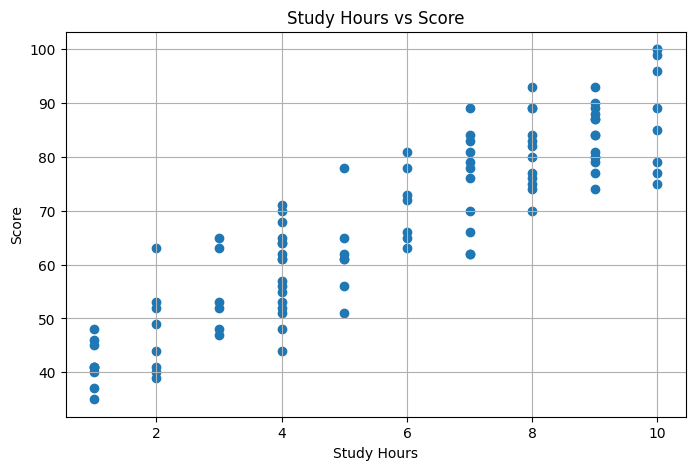

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["study_hours"],
    df["score"]
)

plt.title("Study Hours vs Score")
plt.xlabel("Study Hours")
plt.ylabel("Score")
plt.grid(True)

plt.show()

# 17. Histogram

Histogram برای دیدن توزیع یک متغیر عددی مفید است.

مثلاً می‌خواهیم ببینیم نمرات بیشتر در چه محدوده‌ای قرار دارند.


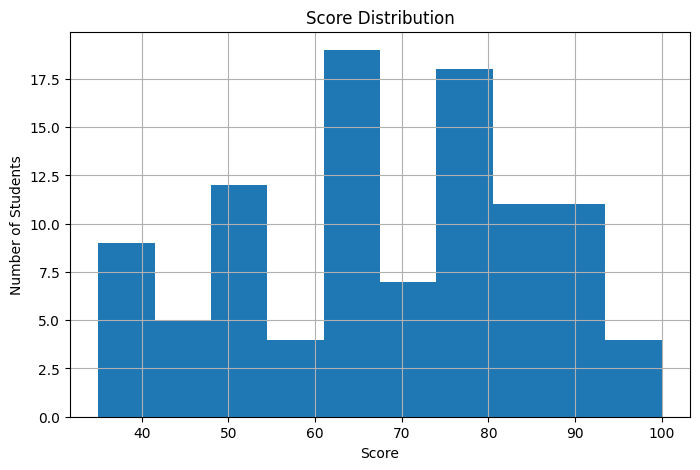

In [21]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["score"],
    bins=10
)

plt.title("Score Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.grid(True)

plt.show()

# 18. Bar Chart

برای نمایش میانگین نمره شهرها، Bar Chart مناسب است.


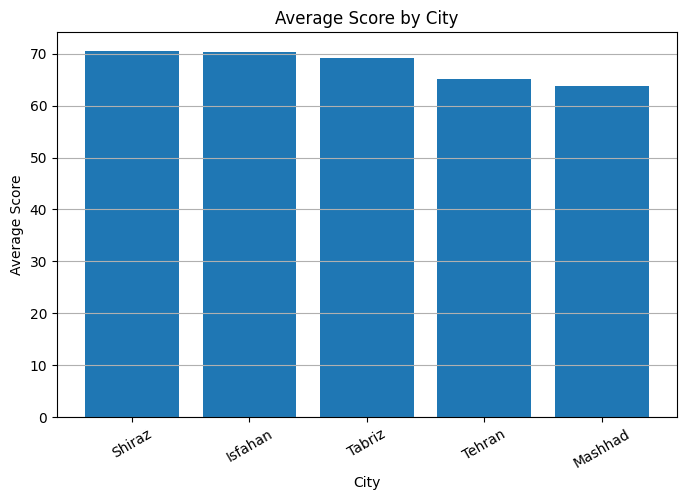

In [22]:
city_score = (
    df.groupby("city")["score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

plt.bar(
    city_score.index,
    city_score.values
)

plt.title("Average Score by City")
plt.xlabel("City")
plt.ylabel("Average Score")
plt.xticks(rotation=30)
plt.grid(axis="y")

plt.show()

# 19. Box Plot و داده‌های پرت

Box Plot برای دیدن شکل توزیع و کمک به شناسایی داده‌های پرت مفید است.


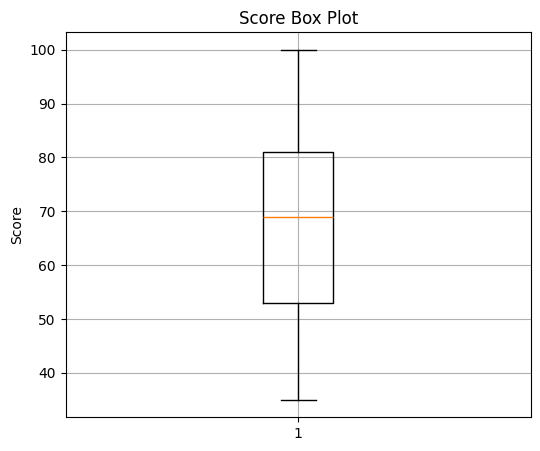

In [23]:
plt.figure(figsize=(6, 5))

plt.boxplot(
    df["score"]
)

plt.title("Score Box Plot")
plt.ylabel("Score")
plt.grid(True)

plt.show()

# 20. یک سؤال تحلیلی واقعی

تا اینجا فقط دستور اجرا نکرده‌ایم؛ یک سؤال واقعی را بررسی می‌کنیم:

> آیا دانشجویانی که بیشتر مطالعه می‌کنند، معمولاً نمره بالاتری می‌گیرند؟

سه ابزار داریم:

1. نگاه به جدول
2. محاسبه Correlation
3. رسم Scatter Plot

اگر هر سه شواهد مشابهی بدهند، نتیجه تحلیلی ما قابل اتکاتر می‌شود.


In [24]:
# بررسی میانگین نمره بر اساس تعداد ساعات مطالعه
study_summary = (
    df.groupby("study_hours")["score"]
      .agg(["count", "mean", "min", "max"])
      .sort_index()
)

display(study_summary)

,count,mean,min,max
study_hours,,,,
1,9,41.555556,35,48
2,8,47.625000,39,63
3,6,54.666667,47,65
4,17,58.941176,44,71
5,7,62.000000,51,78
6,7,71.142857,63,81
7,11,75.454545,62,89
8,12,81.000000,70,93
9,14,83.785714,74,93


# 21. آماده‌سازی برای Machine Learning

اکنون وارد بخش ML می‌شویم.

دو مفهوم بسیار مهم:

## Feature

ورودی‌هایی که مدل از آن‌ها برای پیش‌بینی استفاده می‌کند.

در این پروژه:

```text
age
study_hours
attendance
```

را Feature در نظر می‌گیریم.

## Target

چیزی که قرار است پیش‌بینی شود.

در پروژه ما:

```text
score
```

Target است.


In [25]:
X = df[[
    "age",
    "study_hours",
    "attendance"
]]

y = df["score"]

print("X:")
display(X.head())

print("\ny:")
display(y.head())

X:


,age,study_hours,attendance
0,18,4,74
1,28,2,97
2,18,4,74
3,18,4,94
4,25,5,60



y:


0    52
1    63
2    64
3    71
4    51
Name: score, dtype: int64

# 22. Train / Test Split

نباید مدل را روی تمام داده آموزش دهیم و سپس با همان داده ارزیابی کنیم.

داده را به دو بخش تقسیم می‌کنیم:

```text
Training Data → برای یادگیری
Testing Data  → برای ارزیابی روی داده ندیده
```

در اینجا:

```python
test_size=0.2
```

یعنی 20 درصد برای Test و 80 درصد برای Training.


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (80, 3)
X_test : (20, 3)
y_train: (80,)
y_test : (20,)


# 23. ساخت اولین مدل — Linear Regression

چون `score` یک مقدار عددی است، مسئله ما در این مثال از نوع **Regression** است.

مدل:

```text
Linear Regression
```

ایده ساده مدل این است که تلاش کند رابطه‌ای تقریباً خطی بین Featureها و Target پیدا کند.


In [27]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model trained successfully.")

Model trained successfully.


# 24. پیش‌بینی

اکنون مدل داده‌های Test را ندیده است.

با `predict()` پیش‌بینی انجام می‌دهیم:


In [28]:
predictions = model.predict(X_test)

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(predictions, 2)
})

display(result.head(10))

,Actual,Predicted
0,61,62.80
1,61,56.92
2,55,57.10
3,46,45.84
4,80,75.50
5,44,39.99
6,76,69.12
7,90,83.39
8,79,72.58
9,52,56.02


# 25. ارزیابی مدل

برای Regression چند معیار مهم داریم.

## MAE

میانگین قدرمطلق خطاها:

```text
MAE = متوسط |Actual - Predicted|
```

هرچه کوچک‌تر بهتر.

## MSE

خطاها را به توان دو می‌رساند و نسبت به خطاهای بزرگ حساس‌تر است.

## RMSE

ریشه MSE است و در واحد Target قابل تفسیرتر است.

## R²

در یک تفسیر ساده، نشان می‌دهد مدل چه مقدار از تغییرپذیری Target را توضیح می‌دهد.

> هیچ معیار واحدی به تنهایی کیفیت مدل را کامل توصیف نمی‌کند.


In [29]:
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 3.9075477959039957
MSE : 21.1493602540531
RMSE: 4.59884336046066
R²  : 0.9113085622156626


# 26. پیش‌بینی برای یک دانشجوی جدید

فرض کنید دانشجوی جدیدی داریم:

- سن: 22
- ساعات مطالعه: 7
- حضور: 95

و می‌خواهیم نمره تقریبی او را پیش‌بینی کنیم.


In [30]:
new_student = pd.DataFrame({
    "age": [22],
    "study_hours": [7],
    "attendance": [95]
})

predicted_score = model.predict(new_student)[0]

print("Predicted score:", round(predicted_score, 2))

Predicted score: 81.6


# 27. ذخیره Dataset پردازش‌شده

اکنون دو ستون جدید داریم:

```text
passed
grade
```

می‌توانیم Dataset جدید را ذخیره کنیم.

برای اینکه index داخلی DataFrame به عنوان ستون اضافه نشود:

```python
index=False
```


In [31]:
processed_path = "students_100_processed.csv"

df.to_csv(
    processed_path,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:", processed_path)

Saved: students_100_processed.csv


# 28. خواندن CSV پردازش‌شده

می‌توانیم فایل تولیدشده را دوباره بخوانیم:


In [32]:
df_processed = pd.read_csv("students_100_processed.csv")

print("Shape:", df_processed.shape)
display(df_processed.head())

Shape: (100, 9)


,student_id,name,age,city,study_hours,attendance,score,passed,grade
0,1,Mina,18,Tabriz,4,74,52,True,Average
1,2,Mina,28,Isfahan,2,97,63,True,Average
2,3,Sara,18,Tehran,4,74,64,True,Average
3,4,Nazanin,18,Isfahan,4,94,71,True,Good
4,5,Hassan,25,Isfahan,5,60,51,True,Average


# 29. CSV بزرگ‌تر — یک نکته کاربردی

اگر فایل CSV بسیار بزرگ باشد، لازم نیست همیشه کل آن را یک‌جا وارد حافظه کنیم.

مثلاً:

```python
chunks = pd.read_csv(
    "large_file.csv",
    chunksize=10000
)

for chunk in chunks:
    # پردازش هر بخش
    ...
```

این روش برای Datasetهای بزرگ می‌تواند مناسب‌تر باشد.

همچنین ممکن است لازم باشد از:

```python
sep=";"
```

برای فایل‌هایی با جداکننده `;` یا از:

```python
encoding="utf-8"
```

برای Encoding مناسب استفاده کنیم.


# 30. Data Leakage و Overfitting — دو مفهوم مهم

## Data Leakage

یعنی اطلاعاتی که نباید در فرآیند آموزش مدل حضور داشته باشد، به شکل نادرست وارد آموزش شود.

اصل مهم:

> اطلاعات Test نباید برای یادگیری مدل لو برود.

## Overfitting

مدل روی Training Data بسیار خوب است، اما روی داده جدید ضعیف عمل می‌کند.

به زبان ساده:

```text
Underfitting → مدل زیادی ساده است
Good Fit     → تعادل مناسب
Overfitting  → مدل بیش از حد به Training وابسته شده
```


# 31. پروژه نهایی تمرینی

اکنون بدون نگاه کردن به کدهای بالاتر، سعی کنید برنامه‌ای بنویسید که:

1. `students_100.csv` را بخواند.
2. تعداد سطر و ستون را نمایش دهد.
3. Missing Valueها را بررسی کند.
4. 10 دانشجوی برتر را نشان دهد.
5. میانگین نمره هر شهر را محاسبه کند.
6. میانگین ساعات مطالعه را به دست آورد.
7. Correlation بین `study_hours` و `score` را محاسبه کند.
8. Scatter Plot رسم کند.
9. Histogram نمرات را رسم کند.
10. `passed` را بسازد.
11. داده را به `X` و `y` تقسیم کند.
12. Train/Test Split انجام دهد.
13. Linear Regression بسازد.
14. Prediction انجام دهد.
15. MAE و R² را محاسبه کند.
16. برای یک دانشجوی جدید نمره پیش‌بینی کند.
17. Dataset پردازش‌شده را ذخیره کند.

### چالش اضافه

مدل را یک بار فقط با:

```text
study_hours
```

بسازید و بار دیگر با:

```text
age + study_hours + attendance
```

بسازید.

سپس `MAE` و `R²` را مقایسه کنید.

این تمرین شما را با مفهوم **Feature Selection** به‌صورت عملی آشنا می‌کند.


# 32. Cheat Sheet سریع

## NumPy

```python
import numpy as np

a = np.array([1, 2, 3])

a.shape
a.ndim
a.size
a.dtype

np.mean(a)
np.median(a)
np.min(a)
np.max(a)
np.sum(a)
np.std(a)
```

## Pandas

```python
import pandas as pd

df = pd.read_csv("students_100.csv")

df.head()
df.tail()
df.info()
df.describe()

df.shape
df.columns

df["score"]
df[["name", "score"]]

df[df["score"] > 80]

df.sort_values("score", ascending=False)

df.isnull().sum()
df.duplicated().sum()

df.groupby("city")["score"].mean()

df.to_csv("output.csv", index=False)
```

## Matplotlib

```python
import matplotlib.pyplot as plt

plt.plot(x, y)
plt.scatter(x, y)
plt.bar(x, y)
plt.hist(data)
plt.boxplot(data)

plt.title("Title")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()
```

## Scikit-learn

```python
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)
```

## Evaluation

```python
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)
```


# جمع‌بندی

در این پروژه از یک فایل CSV با **100 رکورد** شروع کردیم و به یک مدل Machine Learning رسیدیم.

مسیر واقعی که تمرین کردیم:

```text
CSV
 ↓
Pandas
 ↓
Explore
 ↓
Clean
 ↓
Analyze
 ↓
NumPy
 ↓
Matplotlib
 ↓
Features / Target
 ↓
Train / Test Split
 ↓
Scikit-learn
 ↓
Model
 ↓
Prediction
 ↓
Evaluation
```

مهم‌ترین نکته این است که این کتابخانه‌ها را جدا از هم حفظ نکنیم.

در پروژه واقعی:

- **Pandas** معمولاً مرکز کار با Dataset است.
- **NumPy** برای محاسبات عددی و آرایه‌ها بسیار مهم است.
- **Matplotlib** به ما کمک می‌کند داده را ببینیم و الگوها را بهتر بفهمیم.
- **Scikit-learn** بخش مهمی از مسیر کلاسیک Machine Learning را پوشش می‌دهد.

بعد از تسلط بر این مسیر، گام‌های منطقی بعدی عبارت‌اند از:

```text
Seaborn
Statistics
EDA عمیق‌تر
Data Cleaning پیشرفته
Feature Engineering
Classification
Decision Tree
Random Forest
Cross Validation
Hyperparameter Tuning
Pipelines
```
